In [1]:
# Last mod: FA Oct 27 - adapted notebook from Jaume's TFG

# Analysing chemistry space of the GALAH DR3 RC catalogue 
## with XD

In [2]:
import numpy as np
#import matplotlib.pylab as plt
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import colors
from matplotlib.colors import LogNorm
from matplotlib import patches
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import NullFormatter

import astropy.table
from astropy.table import Table, Column, MaskedColumn 
from astropy.visualization import astropy_mpl_style
from scipy.stats import gaussian_kde
import seaborn as sns
import os.path

from time import time
from sklearn import manifold, datasets

import umap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from itertools import product

import obtain_data

#from astroML.plotting import setup_text_plots
#setup_text_plots(fontsize=16, usetex=True)

In [7]:
import importlib   #package
importlib.reload(obtain_data)

galah_rc = obtain_data.galah_dr3_rc()

In [8]:
galah_rc.get_ndimspace(norm=None)

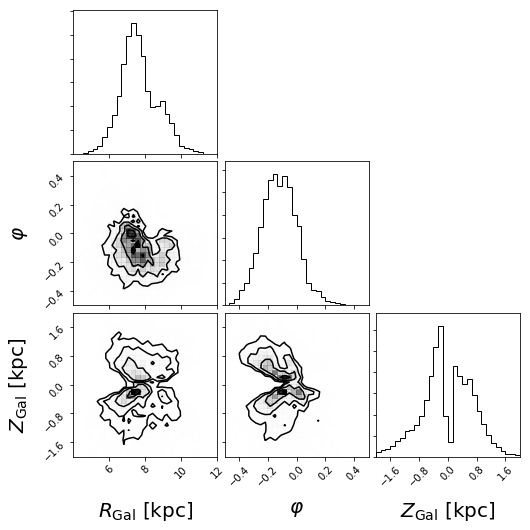

In [21]:
import corner
figure = corner.corner(np.array([galah_rc.data["R_Rzphi"],galah_rc.data["phi_Rzphi"], 
                                 galah_rc.data["z_Rzphi"]]).T, 
                       weights=None, bins=30, 
                       range=[[4,12],[-.5,0.5],[-2,2]],
                       labels=[r"$R_{\rm Gal}$ [kpc]", r"$\varphi$", 
                               r"$Z_{\rm Gal}$ [kpc]"],
                       quantiles=[0.16, 0.5, 0.84],plot_datapoints=False,
                       show_titles=False, label_kwargs={"fontsize": 20})
plt.savefig("../im/corner_rphiz.png")

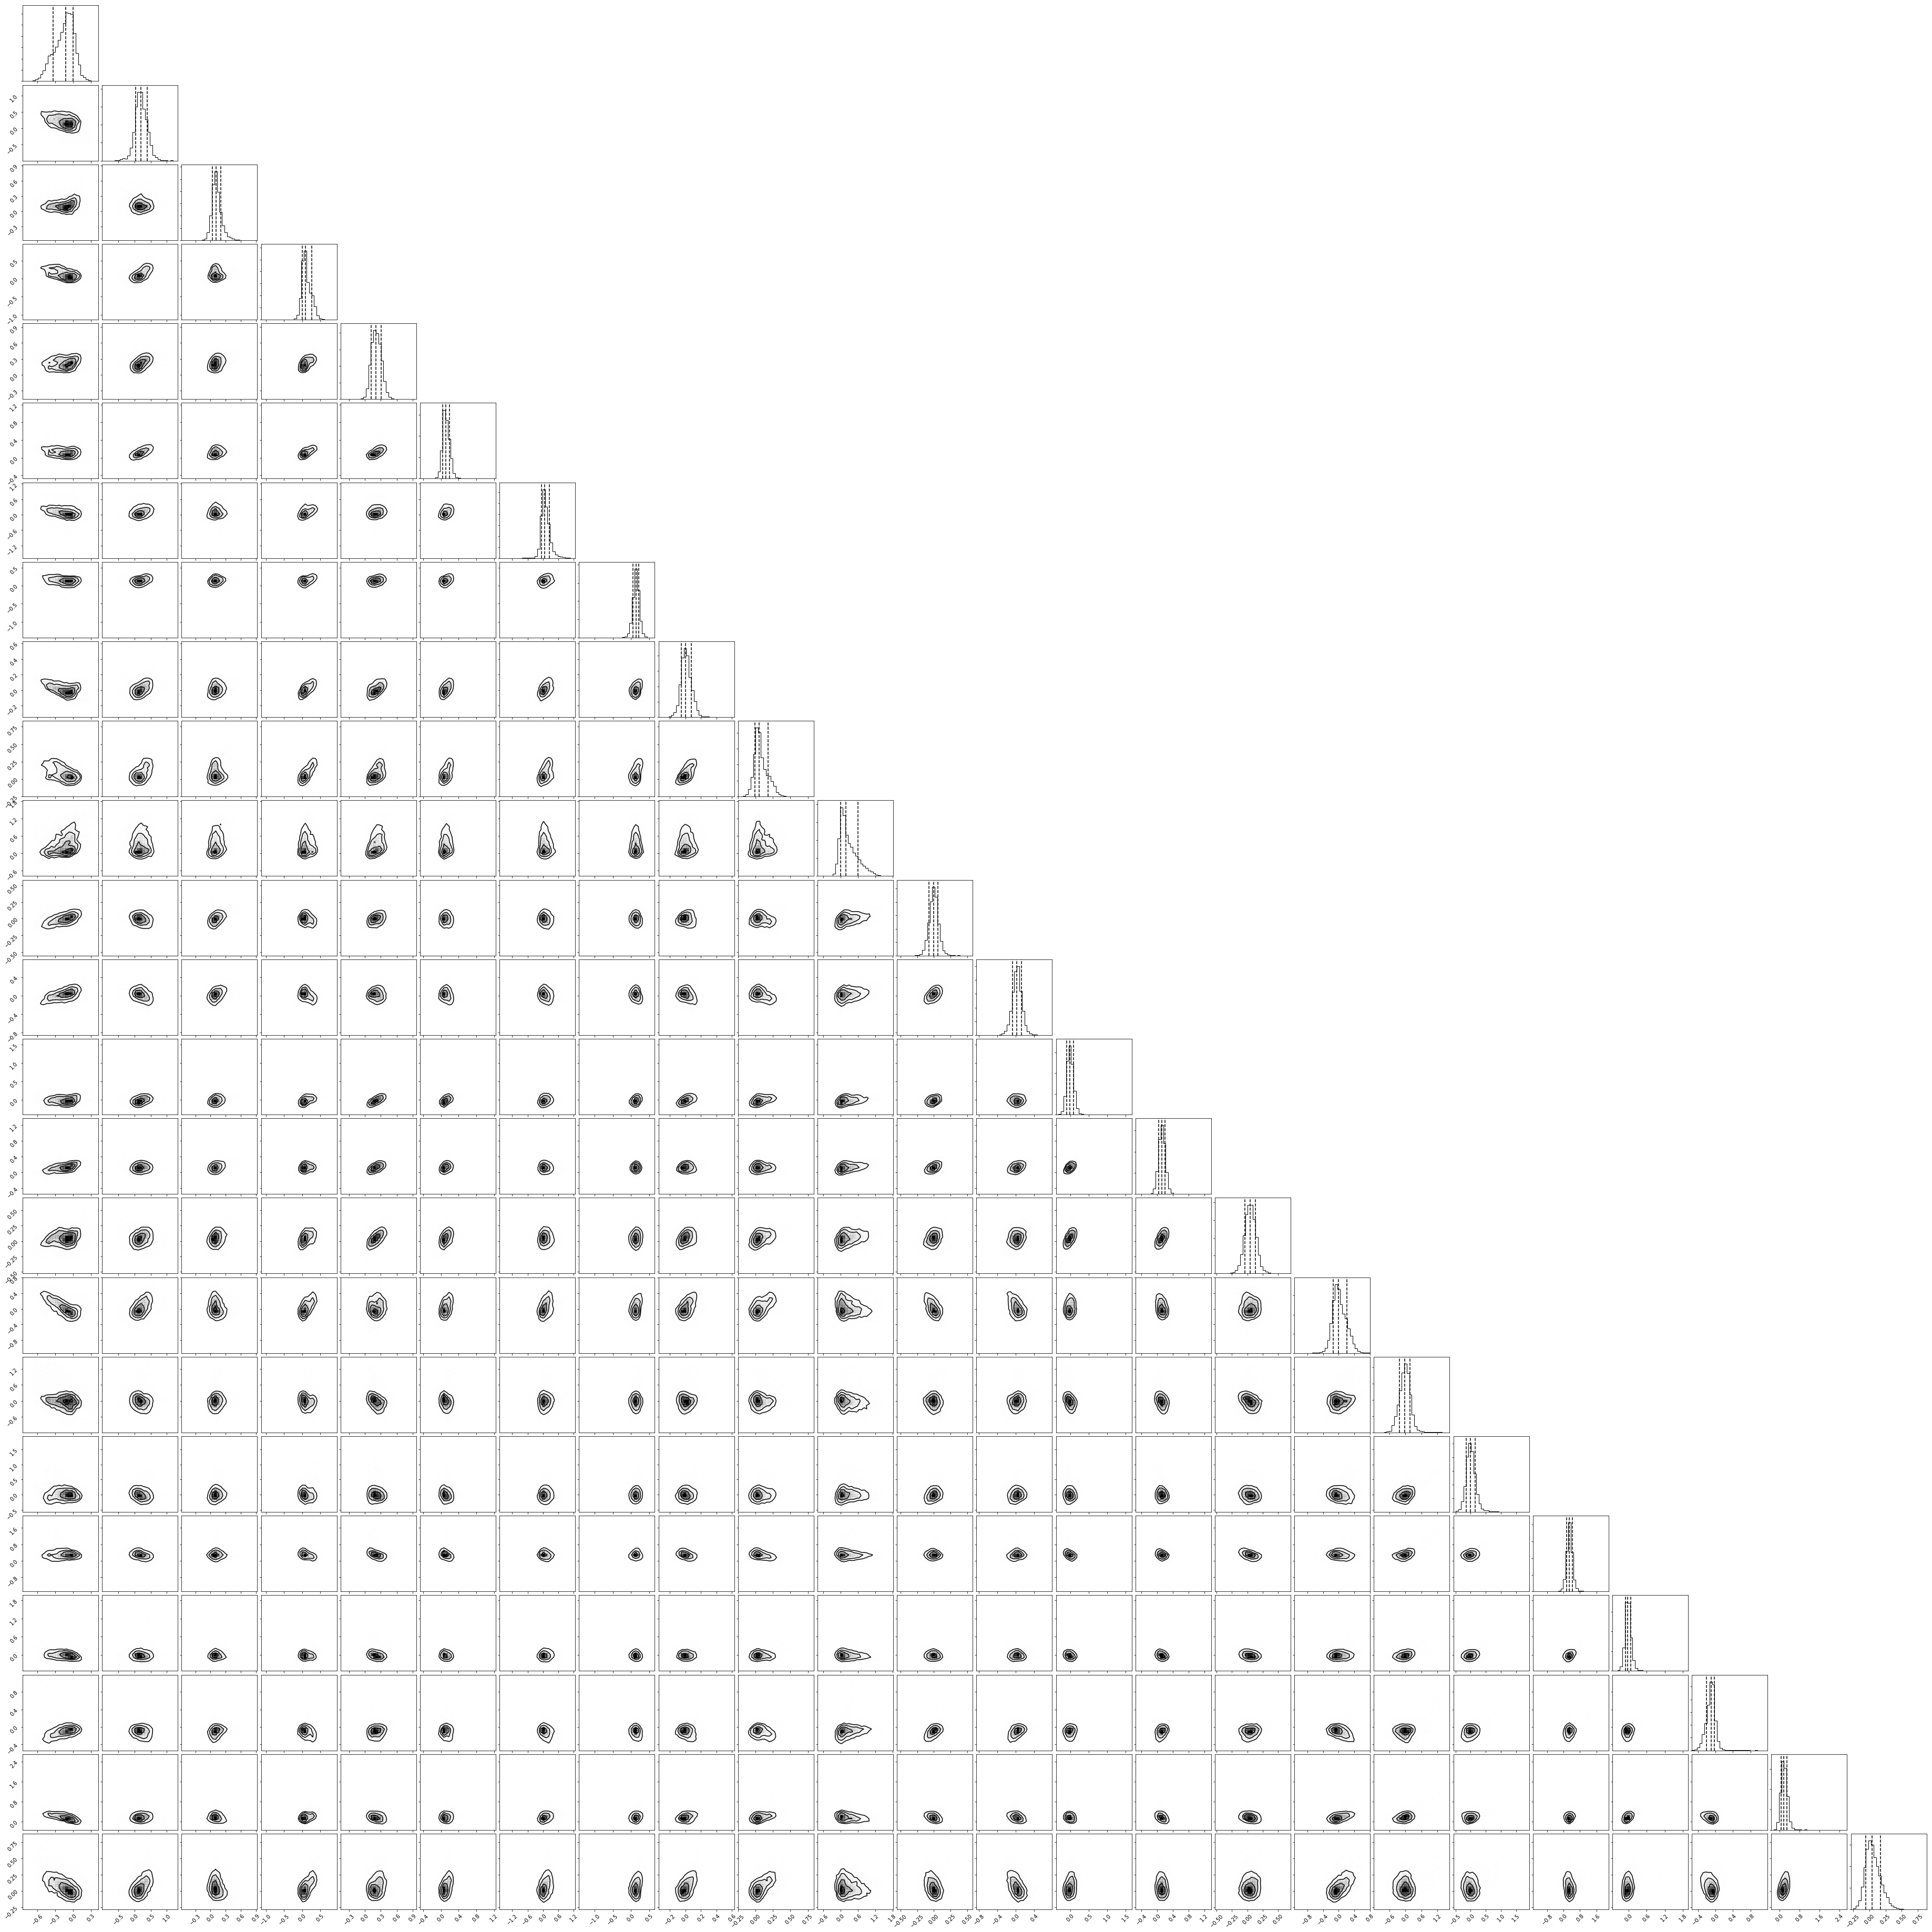

In [22]:
figure = corner.corner(galah_rc.X, 
                       weights=None, bins=30, 
                       #range=[[4,12],[-.5,0.5],[-2,2]],
                       #labels=[r"$R_{\rm Gal}$ [kpc]", r"$\varphi$", 
                       #        r"$Z_{\rm Gal}$ [kpc]"],
                       quantiles=[0.16, 0.5, 0.84],plot_datapoints=False,
                       show_titles=False, label_kwargs={"fontsize": 20})
plt.savefig("../im/corner_abundancespace.png")

ValueError: supplied range of [nan, nan] is not finite

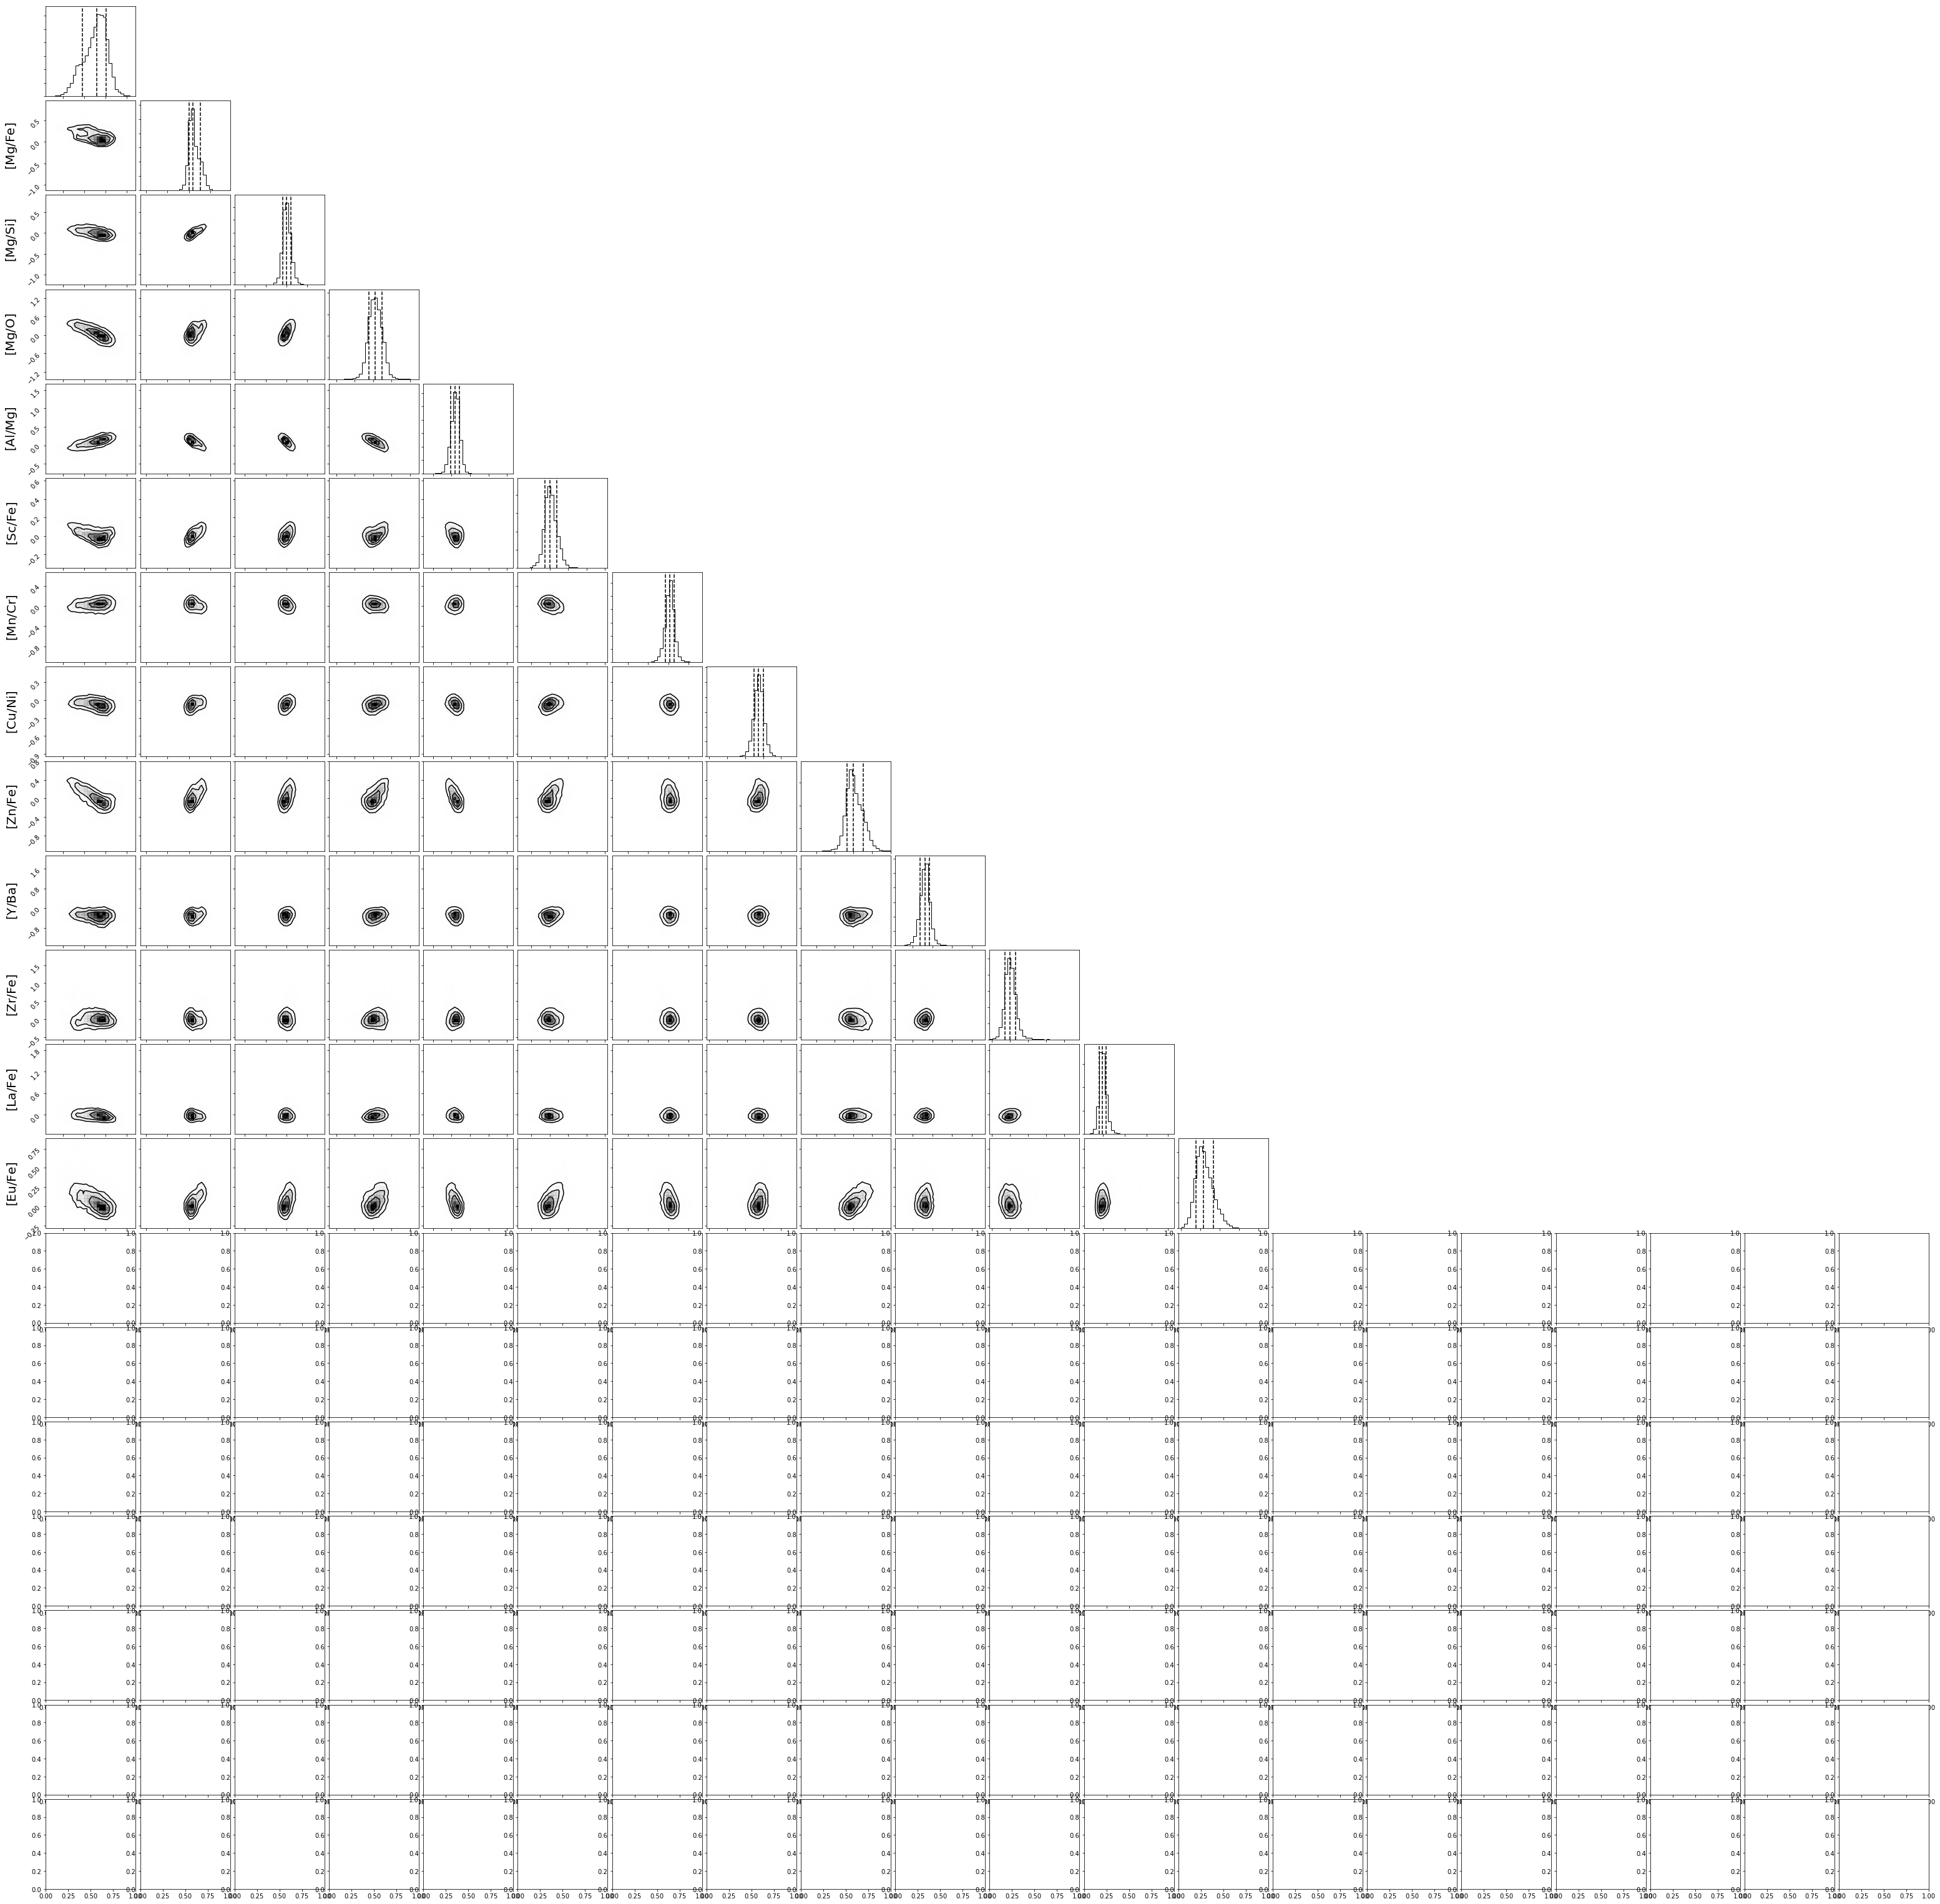

In [25]:
galah_rc.get_umap_tsne_colours(p=80, lr=10, nn=80, md=0.1, 
                              metric="euclidean", version="")
figure = corner.corner(np.array(galah_rc.colors).T, 
                       weights=None, bins=30, 
                       #range=[[4,12],[-.5,0.5],[-2,2]],
                       labels=galah_rc.titles,
                       quantiles=[0.16, 0.5, 0.84],plot_datapoints=False,
                       show_titles=False, label_kwargs={"fontsize": 20})
plt.savefig("../im/corner_summary.png")